# Demo 02: Fine-tune EpiZoo on custom scATAC-seq data

This notebook demonstrates how to fine-tune **EpiZoo** on a new scATAC-seq dataset.

Starting from a pretrained EpiZoo model, users can fine-tune the model to their own scATAC-seq data. After fine-tuning, EpiZoo can be used to extract improved cell embeddings for downstream single-cell analyses.

## Required files

Before running this notebook, please prepare the following files:

- **`model.pth`**: The pretrained EpiZoo model checkpoint.

## Output

This notebook will generate:

- Fine-tuned EpiZoo model checkpoint (`finetuned_model.pth`)
- EpiZoo cell embeddings extracted from the fine-tuned model (`cell_embeddings.npy`)
- An AnnData object containing fine-tuned EpiZoo embeddings (`adata_cell_embeddings.h5ad`)
- UMAP visualization of cell embeddings

In [1]:
import os
import sys

# Add EpiZoo root directory
PROJECT_ROOT = os.path.abspath("../")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

## Step 1: Data processing

To prepare dataset for EpiZoo, we perform the following preprocessing steps:

1. **TF-IDF transformation:** Convert the raw count matrix into TF-IDF normalized values, which quantify the relative importance of accessible cCREs within each cell.

2. **Cell sentence generation:** Rank accessible cCREs according to their TF-IDF scores and convert each cell into a compact cell sentence composed of cCRE indices, which serves as the input for EpiZoo.

In [2]:
import scanpy as sc
import numpy as np
import pandas as pd

from epizoo.data.processing import compute_tfidf, filter_cCREs, generate_cell_sentences

# 1. Load required data files
# Load the dataset
adata_file_path = "../data/Fang2021_downsampled_2000_cells.h5ad"
adata = sc.read_h5ad(adata_file_path)
print(f"Anndata: {adata}")

# Load the cCRE document frequency data (for mouse here)
df_file_path = "../data/cCRE_frequencies_mouse.npy"
df = np.load(df_file_path)
print(f"Document Frequency: {df}")

# Load the cCRE filter index (for mouse here)
filter_index_file_path = "../data/cCRE_filter_idx_mouse.csv"
filter_index = pd.read_csv(filter_index_file_path,index_col=0)['idx'].values
print(f"Filter Index: {filter_index}")

# 2. Preprocess the data
# Perform TF-IDF transformation
adata = compute_tfidf(adata, df, cell_number=12500000)

# Filter cCRE
adata = filter_cCREs(adata, filter_idx=filter_index, species=1)

# Generate cell sentences
adata = generate_cell_sentences(adata, species=1, species_offset=700460)
print(f"Cell Sentences:\n{adata.obs['cell_indices'][:5]}")

/home/jiangqun/miniconda3/envs/cellemu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Anndata: AnnData object with n_obs × n_vars = 2000 × 1341077
    obs: 'prefix_barcode', 'sample name', 'barcode', 'tsne1', 'tsne2', 'celltype', 'celltype2', 'batch', 'dataset'
Document Frequency: [ 9086. 20040. 10906. ...  1046.  1051.  3763.]
Filter Index: [      3       4       8 ... 1341044 1341059 1341062]
TF-IDF completed. TF-IDF matrix stored in adata.X
Matrix shape: (2000, 1341077)
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Data type: float32
Non-zero entries: 6,703,562
Sparsity: 99.7501%
Non-zero value min: 0.470534
Non-zero value max: 329.738953
Non-zero value mean: 12.603610
Non-zero value median: 8.776130
--------------------------------------------------
Accessible cCREs per cell:
  Mean: 3351.78
  Median: 2422.00
  Min: 494
  Max: 24220
Filtered cCREs: 814020 features retained.
Cell Sentences:
Fang2021_GSM3611838_CEMBA180305_2B_AGAGCAGTTTCCATCCTGCTGGTATTACGACC    [979641, 1263399, 1336016, 1012267, 1181117, 1...
Fang2021_GSM3611841_CEMBA180312_3B_GCTCTAAGCTAATGCTC

## Step 2: Create Dataset and DataLoader

After generating cell sentences, we construct `CellDataset` and DataLoader for model fine-tuning. Each cell is represented as a sequence of tokens with special tokens [CLS] and [SEP].

In [3]:
from epizoo.data.datasets import CellDataset, collate_fn
from torch.utils.data import DataLoader

# Create a dataset and dataloader for inference
human_vocab_size = 700460
mouse_vocab_size = 814020
celldataset = CellDataset(
    cell_sentences=adata.obs['cell_indices'].values,
    species=[1] * adata.n_obs,
    cca_alpha=1,
    human_num_ccres=human_vocab_size,
    mouse_num_ccres=mouse_vocab_size,
)
dataloader = DataLoader(
    celldataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn,
)

## Step 3: Load the pretrained EpiZoo model

We load the pretrained model checkpoint for fine-tuning.

In [4]:
import torch
from epizoo.models.epizoo import EpiZooConfig, EpiZoo

# Load pretrained model
model_path = "/data/lizhen/epizoo/models/pretrained_EpiZoo.pth"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Initialize EpiZoo model
config = EpiZooConfig(
    vocab_size = human_vocab_size + mouse_vocab_size + 4,
    human_vocab_size = human_vocab_size,
    mouse_vocab_size = mouse_vocab_size,
    num_layers = 30,
)
pretrained_model = EpiZoo(cfg=config)

# Load pretrained weights
state_dict = torch.load(model_path, map_location="cpu")
pretrained_model.load_state_dict(state_dict, strict=False)

# Move model to device
pretrained_model = pretrained_model.to(device)

print("EpiZoo model loaded successfully.")

EpiZoo model loaded successfully.


## Step 4: Model fine-tuning

We fine-tune the pretrained EpiZoo model on the new scATAC-seq dataset using `EpiZooFinetuneTrainer`.

The fine-tuned model checkpoint will be saved for downstream inference.

In [5]:
from epizoo.train.finetune import EpiZooFinetuneTrainer, FineTuneConfig, LoRAConfig

# Fine-tuning configuration
ft_cfg = FineTuneConfig(
    mode="sr_cca",
    output_dir="/data/lizhen/epizoo/models/finetuned_model",
    max_steps=1000,
    save_steps=200,
    log_steps=100,
    keep_last=2,
    lr=1e-5,
    warmup_steps=100,
    device=device,
)

# Optional LoRA configuration
# Set all False for full parameter fine-tuning
lora_cfg = LoRAConfig(
    use_embedding=False,
    use_transformer=False,
    use_decoder=False,
)

trainer = EpiZooFinetuneTrainer(
    model=pretrained_model,
    train_loader=dataloader,
    cfg=ft_cfg,
    lora_cfg=lora_cfg,
)

# Start fine-tuning
finetuned_model = trainer.train()

Frozen seq_emb.
Total parameters:     2,615,692,905
Trainable parameters: 1,840,277,097
Frozen parameters:    775,415,808
Step 100 | lr=1.000e-05 | loss=0.9353 | sr=0.4424 | cca=0.4929 | cca_pos_acc=0.7615 | cca_neg_acc=0.7990 | auroc=0.8583 | auprc=0.8718
Step 200 | lr=1.000e-05 | loss=0.9629 | sr=0.4771 | cca=0.4858 | cca_pos_acc=0.6978 | cca_neg_acc=0.8433 | auroc=0.8369 | auprc=0.8521
Checkpoint saved to /data/lizhen/epizoo/models/finetuned_model/202607140532_200.pth
Step 300 | lr=1.000e-05 | loss=0.9261 | sr=0.4533 | cca=0.4728 | cca_pos_acc=0.7874 | cca_neg_acc=0.8140 | auroc=0.8705 | auprc=0.8822
Step 400 | lr=1.000e-05 | loss=0.9130 | sr=0.4427 | cca=0.4703 | cca_pos_acc=0.7676 | cca_neg_acc=0.8411 | auroc=0.8785 | auprc=0.9421
Checkpoint saved to /data/lizhen/epizoo/models/finetuned_model/202607140535_400.pth
Step 500 | lr=9.000e-06 | loss=0.9210 | sr=0.4494 | cca=0.4716 | cca_pos_acc=0.6345 | cca_neg_acc=0.8014 | auroc=0.7887 | auprc=0.8028
Epoch 1 finished. Time: 416.03s
Ste

## Step 5: Extract cell embeddings using the fine-tuned model

We use the `extract_cell_embeddings` function to compute cell embeddings using the fine-tuned model.

In [6]:
from epizoo.inference.embeddings import extract_cell_embeddings
from epizoo.data.datasets import InferenceCellDataset, inference_collate_fn

# Create a dataset and dataloader for inference
inference_dataset = InferenceCellDataset(
    cell_sentences=adata.obs['cell_indices'].values,
    species=[1] * adata.n_obs,
)
inference_dataloader = DataLoader(
    inference_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=inference_collate_fn,
)

# Extract cell embeddings
cell_embeddings = extract_cell_embeddings(
    finetuned_model,
    inference_dataloader,
    device=device,
)
print(f"Completed. Cell embeddings shape: {cell_embeddings.shape}")

Extracting cell embeddings: 100%|██████████| 63/63 [00:35<00:00,  1.79it/s]

Completed. Cell embeddings shape: (2000, 512)


## Step 6: UMAP visualization

We perform UMAP visualization to project the cell embeddings into a 2D space.

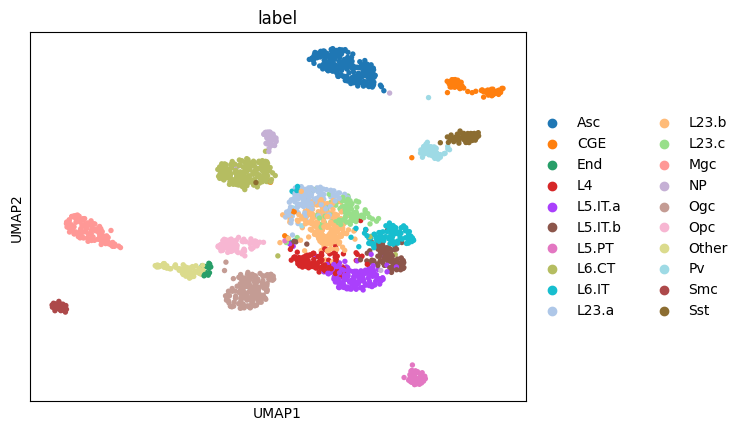

In [7]:
from epizoo.visualization import run_umap

# Run UMAP on the extracted cell embeddings
adata = run_umap(
    cell_embeddings,
    labels=adata.obs['celltype'].values,
    label_key="label",
    output_file=None,
    n_neighbors=15,
    random_state=2020,
    show=True,
)